# Initialization


In [5]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import earthaccess
from datetime import date, datetime
from tqdm.auto import tqdm
import gc
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.io.shapereader as shpreader
from datetime import date
import io
import requests
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
earthaccess.login(persist=True)  # authenticate with NASA Earthdata

# output folders for clipped netcdf files 
AOP_CLIP_DIR, BB_CLIP_DIR = "granule_cache/aop_clipped", "granule_cache/bb_clipped"
for p in (AOP_CLIP_DIR, BB_CLIP_DIR):
    os.makedirs(p, exist_ok=True)

# pier location + transect line 
PIER_LAT, PIER_LON = 32.8679, -117.2619
BEARING_DEG, MAX_DIST_KM, N_STEPS = 260, 25, 200
bbox = (-118, 32, -117, 33)  # west, south, east, north - granule search + clip area
BAD_BITS = (1 << 1) | (1 << 9)  # LAND | CLDICE flag bits to exclude
NRT_LOOKBACK_DAYS = 60  # dates this recent use the near-real-time (NRT) product instead
CHUNK_SIZE = 20  # granules opened at once per batch - bounds peak memory regardless of date range

PN_THRESHOLD = 10000  # cells/L - change this single value to reclassify every day
GROUP_KNOWN, GROUP_NO_PS = "Known PS", "No PS but High CH"

# chl bins/threshold
BIN_RANGES = {"low": (0.5, 1.0), "mid": (1.0, 2.0), "high": (2.0, 4.0), "very_high": (4.0, 8.0)}
NOTE_THRESHOLD = 3.5

# dates 
CELL_COUNTS = {
    date(2024, 3, 15): 0,
    date(2024, 3, 17): 0, date(2024, 4, 15): 0, date(2024, 4, 16): 0,
    date(2024, 4, 19): 0, date(2024, 4, 20): 0, date(2024, 4, 28): 0,
    date(2024, 5, 21): 0, date(2024, 5, 30): 0, date(2024, 6, 14): 0,
    date(2024, 6, 18): 0, date(2024, 6, 19): 0, date(2024, 6, 20): 0,
    date(2024, 6, 24): 2905, date(2024, 6, 25): 2905, date(2024, 6, 26): 2905,
    date(2024, 6, 27): 2905, date(2024, 7, 2): 1252, date(2024, 7, 6): 626,
    date(2024, 8, 11): 2503, date(2024, 8, 17): 0, date(2024, 8, 18): 0,
    date(2024, 8, 19): 0, date(2024, 8, 23): 0, date(2024, 8, 24): 0,
    date(2024, 10, 10): 0, date(2024, 10, 11): 0, date(2024, 10, 19): 0,
    date(2024, 10, 20): 0, date(2024, 10, 21): 0, date(2024, 10, 22): 0,
    date(2024, 10, 23): 0, date(2024, 10, 25): 0, date(2024, 10, 26): 0,
    date(2024, 10, 27): 0, date(2024, 10, 30): 0, date(2024, 10, 31): 0,
    date(2024, 11, 1): 0, date(2024, 11, 2): 0, date(2024, 11, 3): 0,
    date(2024, 11, 4): 0, date(2024, 11, 5): 0, date(2024, 11, 7): 0,
    date(2024, 11, 8): 0, date(2024, 11, 9): 0, date(2024, 11, 10): 0,
    date(2024, 11, 11): 0, date(2024, 11, 12): 0, date(2024, 11, 13): 0,
    date(2024, 11, 14): 0, date(2024, 11, 16): 0, date(2024, 11, 17): 0,
    date(2024, 11, 20): 0, date(2024, 11, 21): 0, date(2024, 11, 22): 0,
    date(2024, 11, 25): 0, date(2024, 11, 28): 0, date(2024, 11, 30): 626,
    date(2024, 12, 7): 0, date(2025, 2, 5): 626, date(2025, 3, 4): 0,
    date(2025, 3, 6): 0, date(2025, 3, 8): 2503, date(2025, 3, 9): 2503,
    date(2025, 3, 10): 2503, date(2025, 3, 12): 2503, date(2025, 3, 15): 1877,
    date(2025, 3, 16): 1877, date(2025, 5, 14): 626, date(2025, 5, 19): 1877,
    date(2025, 5, 20): 1877, date(2025, 5, 26): 626, date(2025, 7, 7): 2503,
    date(2025, 7, 8): 2503, date(2025, 7, 9): 2503, date(2025, 7, 29): 0,
    date(2025, 7, 30): 0, date(2025, 8, 2): 0, date(2025, 8, 5): 0,
    date(2025, 8, 6): 0, date(2025, 8, 16): 0, date(2025, 8, 18): 0,
    date(2025, 8, 21): 0, date(2025, 8, 24): 0, date(2025, 8, 26): 0,
    date(2025, 8, 29): 0, date(2025, 8, 30): 0, date(2025, 9, 23): 3755,
    date(2025, 9, 28): 1252, date(2025, 10, 1): 1252, date(2025, 10, 2): 1252,
    date(2025, 10, 4): 0, date(2025, 10, 8): 0, date(2025, 10, 11): 5632,
    date(2025, 10, 12): 5632, date(2025, 10, 27): 0, date(2025, 10, 30): 0,
    date(2025, 11, 4): 0, date(2025, 11, 19): 0, date(2025, 11, 23): 0,
    date(2025, 11, 25): 0, date(2025, 11, 26): 0, date(2025, 12, 4): 0,
    date(2025, 12, 5): 0, date(2025, 12, 6): 0, date(2025, 12, 8): 0,
    date(2025, 12, 28): 1252, date(2026, 1, 10): 0, date(2026, 1, 11): 0,
    date(2026, 1, 13): 0, date(2026, 1, 17): 1641, date(2026, 1, 20): 1641,
    date(2026, 1, 27): 4103, date(2026, 1, 30): 0, date(2026, 2, 2): 0,
    date(2026, 2, 3): 0, date(2026, 2, 4): 0, date(2026, 2, 5): 0,
    date(2026, 2, 6): 0, date(2026, 2, 7): 0, date(2026, 2, 8): 0,
    date(2026, 2, 9): 0, date(2026, 2, 14): 0, date(2026, 2, 22): 0,
    date(2026, 3, 18): 1231, date(2026, 3, 19): 1231, date(2026, 3, 23): 0,
    date(2026, 3, 25): 0, date(2026, 3, 26): 0, date(2026, 3, 28): 0,
    date(2026, 4, 4): 1252, date(2026, 4, 5): 1252, date(2026, 4, 6): 1252,
    date(2026, 4, 8): 1252, date(2026, 4, 11): 1252, date(2026, 4, 13): 1252,
    date(2026, 4, 14): 1252, date(2026, 4, 15): 1252, date(2026, 4, 17): 0,
    date(2026, 4, 18): 0, date(2026, 4, 19): 0, date(2026, 5, 6): 5006,
    date(2026, 5, 9): 3129, date(2026, 5, 14): 3129, date(2026, 5, 21): 2503,
    date(2026, 5, 23): 1252,
    date(2024, 4, 29): 30038, date(2024, 4, 30): 30038, date(2024, 5, 6): 30038,
    date(2024, 5, 7): 30038, date(2024, 5, 9): 30038, date(2024, 5, 10): 6258,
    date(2024, 5, 18): 6258, date(2024, 5, 19): 6258, date(2024, 7, 25): 26143,
    date(2024, 7, 27): 37763, date(2024, 7, 28): 37763, date(2024, 7, 30): 37763,
    date(2024, 7, 31): 37763, date(2024, 12, 9): 35671, date(2024, 12, 16): 35671,
    date(2024, 12, 17): 35671, date(2024, 12, 18): 35671, date(2024, 12, 19): 171000,
    date(2025, 1, 4): 86986, date(2025, 1, 5): 86986, date(2025, 1, 6): 86986,
    date(2025, 1, 7): 86986, date(2025, 1, 9): 86986, date(2025, 1, 10): 37548,
    date(2025, 1, 11): 37548, date(2025, 1, 12): 37548, date(2025, 1, 13): 37548,
    date(2025, 1, 14): 37548, date(2025, 1, 15): 37548, date(2025, 1, 17): 37548,
    date(2025, 1, 18): 16271, date(2025, 1, 21): 16271, date(2025, 1, 27): 20026,
    date(2025, 1, 29): 20026, date(2025, 2, 1): 20026, date(2025, 2, 17): 115000,
    date(2025, 2, 19): 115148, date(2025, 2, 20): 115148, date(2025, 2, 21): 115148,
    date(2025, 2, 23): 115148, date(2025, 3, 18): 242811, date(2025, 3, 19): 242811,
    date(2025, 3, 20): 242811, date(2025, 3, 21): 242000, date(2025, 3, 22): 242811,
    date(2025, 3, 23): 242811, date(2025, 4, 1): 169592, date(2025, 4, 3): 169592,
    date(2025, 4, 4): 17522, date(2025, 4, 5): 17522, date(2025, 4, 20): 90741,
    date(2025, 4, 23): 90741, date(2025, 6, 24): 37009, date(2025, 6, 29): 37009,
    date(2025, 7, 4): 37009, date(2025, 7, 5): 37009, date(2025, 7, 6): 37009,
    date(2025, 7, 23): 8714, date(2025, 7, 25): 8714, date(2025, 7, 26): 8714,
    date(2025, 7, 27): 8714, date(2025, 9, 3): 6884, date(2025, 9, 9): 6884,
    date(2025, 9, 10): 6884, date(2025, 9, 12): 6258, date(2025, 9, 19): 6258,
    date(2025, 10, 16): 8761, date(2025, 10, 17): 8761, date(2025, 10, 18): 8761,
    date(2025, 10, 19): 8761, date(2025, 10, 22): 8761, date(2025, 10, 24): 8761,
    date(2026, 2, 25): 202808, date(2026, 2, 26): 202808, date(2026, 2, 27): 202808,
    date(2026, 2, 28): 202808, date(2026, 3, 1): 202808, date(2026, 3, 3): 202000,
    date(2026, 3, 7): 25032, date(2026, 3, 8): 25032, date(2026, 3, 9): 25032,
    date(2026, 4, 20): 12516, date(2026, 4, 24): 12516, date(2026, 4, 28): 12516,
    date(2026, 4, 29): 12516, date(2026, 5, 1): 12516, date(2026, 5, 29): 6258,
    date(2026, 5, 30): 6258,
}
all_dates = sorted(CELL_COUNTS)

In [3]:

# Find the granule for each date, using the NRT product for recent dates.
# Splits old enough to use the standard/reprocessed product vs. recent enough it needs the Near-Real-Time  product
def resolve_granules(dates, base_short_name):
    today = date.today()
    normal = [d for d in dates if (today - d).days > NRT_LOOKBACK_DAYS]
    nrt = [d for d in dates if (today - d).days <= NRT_LOOKBACK_DAYS]

# For each non empty bucket, searches NASA Earthdata for granules of that product type spanning the min-to-max date range in the bucket, clipped to bbox    
    resolved = {}
    for bucket, short_name in ((normal, base_short_name), (nrt, f"{base_short_name}_NRT")):
        if not bucket:
            continue
        results = earthaccess.search_data(
            short_name=short_name,
            temporal=(f"{min(bucket).isoformat()}T00:00:00", f"{max(bucket).isoformat()}T23:59:59"),
            bounding_box=bbox,)
# Builds a date granule-metadata lookup from the search results        
        idx = {}
        for g in results:  # match each search result to its observation date
            t = g["umm"]["TemporalExtent"]
            beg = t["RangeDateTime"]["BeginningDateTime"] if "RangeDateTime" in t else t["SingleDateTime"]
            idx[datetime.fromisoformat(beg.replace("Z", "+00:00")).date()] = g
        resolved.update({d: idx[d] for d in bucket if d in idx})
    return resolved
    
#Opens a granule as an xarray.DataTree
# opens streamed granule and return (dt, lat, lon, flags)
def open_granule(file):
    dt = xr.open_datatree(file, decode_timedelta=False)
    lat = dt["navigation_data"]["latitude"].values
    lon = dt["navigation_data"]["longitude"].values
    flags = dt["geophysical_data"]["l2_flags"].values.astype(int)
    return dt, lat, lon, flags

# Builds a bbox mask
# Clip spectral variable (Rrs for AOP, bb for BB)
def clip_to_bbox(dt, var_name, wavelength_var="wavelength_3d"):
    west, south, east, north = bbox
    lat_da = dt["navigation_data"]["latitude"]
    lat, lon = lat_da.values, dt["navigation_data"]["longitude"].values
    mask = (lat >= south) & (lat <= north) & (lon >= west) & (lon <= east)
    if not np.any(mask):
        return None

        
    r0, r1 = np.where(np.any(mask, axis=1))[0][[0, -1]]  # row bounds of the bbox
    c0, c1 = np.where(np.any(mask, axis=0))[0][[0, -1]]  # col bounds of the bbox
    row_dim, col_dim = lat_da.dims # Slices the requested spectral variable
    data = dt["geophysical_data"][var_name].isel({row_dim: slice(r0, r1 + 1), col_dim: slice(c0, c1 + 1)}).values
    flags = dt["geophysical_data"]["l2_flags"].isel({row_dim: slice(r0, r1 + 1), col_dim: slice(c0, c1 + 1)}).values.astype(int)
    return xr.Dataset({
        "latitude": (("y", "x"), lat[r0:r1 + 1, c0:c1 + 1]),
        "longitude": (("y", "x"), lon[r0:r1 + 1, c0:c1 + 1]),
        "l2_flags": (("y", "x"), flags),
        var_name: (("y", "x", "wavelength"), data),
        "wavelength": ("wavelength", dt["sensor_band_parameters"][wavelength_var].values),})

# N_STEPS points spaced along BEARING_DEG out to MAX_DIST_KM from the pier
def transect_points():
    dist = np.linspace(0, MAX_DIST_KM, N_STEPS)
    b = np.deg2rad(BEARING_DEG)
    lats = PIER_LAT + dist * np.cos(b) / 111.32
    lons = PIER_LON + dist * np.sin(b) / (111.32 * np.cos(np.deg2rad(PIER_LAT)))
    return lats, lons, dist

# Nearest valid pixel value at each transect point
def sample_and_bin(lat, lon, flags, values, count, obs_date, bin_ranges, note_thr):
    lats, lons, dist = transect_points()
    valid = ((flags & BAD_BITS) == 0) & ~np.isnan(values)  # drop land/cloud/ice + missing data
    out = np.full(N_STEPS, np.nan)
    ys, xs = np.where(valid)
    if len(ys):
        # nearest valid pixel to each transect point 
        d = (lat[ys, xs][None, :] - lats[:, None])**2 + (lon[ys, xs][None, :] - lons[:, None])**2  # (N_STEPS, M)
        idx = np.argmin(d, axis=1)
        out = values[ys[idx], xs[idx]]
    date_str, base = obs_date.isoformat(), (obs_date.year, obs_date.month, obs_date.day, count)
    notes = [(*base, out[i], lats[i], lons[i], dist[i], date_str) for i in range(N_STEPS) if out[i] >= note_thr]
    rows = []
    for label, (lo, hi) in bin_ranges.items():  # keep the highest value in each bin, per day
        in_bin = (out >= lo) & (out < hi)
        if np.any(in_bin):
            best = np.where(in_bin)[0][np.argmax(out[in_bin])]
            rows.append((*base, label, out[best], lats[best], lons[best], date_str))
        else:
            rows.append((*base, label, np.nan, np.nan, np.nan, date_str))
    return rows, notes

# Label each row Known PS vs No PS based on PN_THRESHOLD
def add_group(df):
    df.insert(0, "group", np.where(df["count"] > PN_THRESHOLD, GROUP_KNOWN, GROUP_NO_PS))
    return df

# For each chl pick's GPS point, find the nearest valid bb pixel and pull ONLY that
def bb_spectra_at_picks(lat, lon, flags, bb_da, row_dim, col_dim, wavelengths, picks):
    valid = (flags & BAD_BITS) == 0
    ys, xs = np.where(valid)
    if not len(ys):
        return []

    plats = np.array([p[1] for p in picks])
    plons = np.array([p[2] for p in picks])
    ok = ~np.isnan(plats) & ~np.isnan(plons)

    # nearest valid pixel to each pick point, no KD-tree, vectorized across all picks at once
    d = (lat[ys, xs][None, :] - plats[:, None])**2 + (lon[ys, xs][None, :] - plons[:, None])**2  # (n_picks, M)
    idx = np.argmin(d, axis=1)

    rows = []
    for i, (level, plat, plon) in enumerate(picks):
        if not ok[i]:
            continue
        y, x = int(ys[idx[i]]), int(xs[idx[i]])
        spectrum = bb_da.isel({row_dim: y, col_dim: x}).values  # loads just this one pixel
        rows += [(level, plat, plon, wavelengths[j], spectrum[j]) for j in range(len(wavelengths))]
    return rows
    
# Open CHUNK_SIZE granules at a time
def stream_and_process(resolved, process_fn, label="Processing"):
    items = list(resolved.items())
    with tqdm(total=len(items), desc=label) as pbar:
        for i in range(0, len(items), CHUNK_SIZE):
            chunk = items[i:i + CHUNK_SIZE]
            dates_, granules = zip(*chunk)
            for d, file in zip(dates_, earthaccess.open(list(granules), show_progress=False)):
                process_fn(d, file)
                file.close()
                pbar.update(1)
                gc.collect()  # release this chunk's memory before opening the next batch


print(f"Ready - {len(all_dates)} dates loaded.")

Ready - 234 dates loaded.


## BGC chlorophyll transect and bins
Saves `chl_transect_picks.csv` and `chl_transect_high_notes.csv`. IOP cell needs output

In [ ]:
# stream chlorophyll granules, sample the transect, bin, and save picks/notes.
bgc = resolve_granules(all_dates, "PACE_OCI_L2_BGC")

chl_rows, chl_notes = [], []
picks_by_date = {}  # date -> [(level, lat, lon), ...]


def process_bgc(d, file):
    dt, lat, lon, flags = open_granule(file)
    chl = dt["geophysical_data"]["chlor_a"].values
    dt.close()
    rows, notes = sample_and_bin(lat, lon, flags, chl, CELL_COUNTS[d], d, BIN_RANGES, NOTE_THRESHOLD)
    chl_rows.extend(rows)
    chl_notes.extend(notes)
    picks_by_date[d] = [(r[4], r[6], r[7]) for r in rows]  # (level, lat, lon) per bin


stream_and_process(bgc, process_bgc, label="BGC chlorophyll")
add_group(pd.DataFrame(chl_rows, columns=["year", "month", "day", "count", "level", "chl", "lat", "lon", "date"])).to_csv("chl_transect_picks.csv", index=False)
add_group(pd.DataFrame(chl_notes, columns=["year", "month", "day", "count", "chl", "lat", "lon", "distance_km", "date"])).to_csv("chl_transect_high_notes.csv", index=False)

print(f"BGC done - {len(chl_rows)} bin rows saved to chl_transect_picks.csv (needed by the IOP cell).")
del bgc, chl_rows, chl_notes, picks_by_date
gc.collect()

BGC chlorophyll:   0%|          | 0/232 [00:00<?, ?it/s]

## AOP  reflectance Rrs
Indpendent other then Cell 1

In [ ]:
# AOP: stream reflectance granules and archive the bbox-clipped Rrs as netcdf.
aop = resolve_granules(all_dates, "PACE_OCI_L2_AOP")


def process_aop(d, file):
    dt, *_ = open_granule(file)
    ds = clip_to_bbox(dt, "Rrs")
    dt.close()
    if ds is not None:
        ds.to_netcdf(f"{AOP_CLIP_DIR}/aop_clipped_{d.isoformat()}.nc")


stream_and_process(aop, process_aop, label="AOP reflectance")
print(f"AOP done - clipped netcdfs saved to {AOP_CLIP_DIR}/")
del aop
gc.collect()

## IOP  total backscattering (bb)
Reads `chl_transect_picks.csv` from disk 

In [5]:
# stream backscatter granules, archive the bbox-clipped bb, and pull the full
picks_df = pd.read_csv("chl_transect_picks.csv", parse_dates=["date"])
picks_by_date = {}
for d, g in picks_df.groupby(picks_df["date"].dt.date):
    picks_by_date[d] = list(zip(g["level"], g["lat"], g["lon"]))

bb = resolve_granules(all_dates, "PACE_OCI_L2_IOP")
bb_spectra = []


def process_bb(d, file):
    dt, lat, lon, flags = open_granule(file)
    ds = clip_to_bbox(dt, "bb")
    if ds is not None:
        ds.to_netcdf(f"{BB_CLIP_DIR}/bb_clipped_{d.isoformat()}.nc")
    bb_da = dt["geophysical_data"]["bb"]  # kept lazy - see bb_spectra_at_picks
    row_dim, col_dim = dt["navigation_data"]["latitude"].dims
    wavelengths = dt["sensor_band_parameters"]["wavelength_3d"].values
    picks = bb_spectra_at_picks(lat, lon, flags, bb_da, row_dim, col_dim, wavelengths, picks_by_date.get(d, []))
    dt.close()
    for level, plat, plon, wl, val in picks:
        bb_spectra.append((d.year, d.month, d.day, CELL_COUNTS[d], level, plat, plon, wl, val, d.isoformat()))


stream_and_process(bb, process_bb, label="IOP backscatter")

add_group(pd.DataFrame(bb_spectra, columns=["year", "month", "day", "count", "level", "lat", "lon", "wavelength", "bb", "date"])).to_csv("chl_pick_bb_spectra.csv", index=False)
print(f"IOP done - {len(bb_spectra)} spectrum rows saved to chl_pick_bb_spectra.csv")
del bb, bb_spectra, picks_by_date, picks_df
gc.collect()

IOP backscatter:   0%|          | 0/232 [00:00<?, ?it/s]

IOP done - 8874 spectrum rows saved to chl_pick_bb_spectra.csv


4447

In [3]:
pip install basemap-data-hires

  Using cached basemap_data_hires-2.0.0-py3-none-any.whl.metadata (2.5 kB)
Using cached basemap_data_hires-2.0.0-py3-none-any.whl (91.1 MB)
Note: you may need to restart the kernel to use updated packages.


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

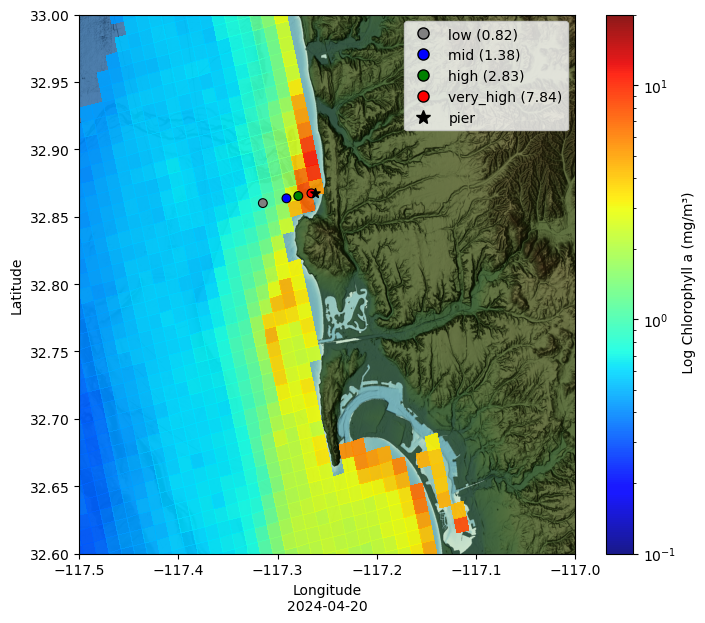

In [8]:

PIER_LAT, PIER_LON = 32.8679, -117.2619
bbox = (-118, 32, -117, 33)  # west, south, east, north
OBS_DATE = date(2024, 4, 20)

# fetch one PACE granule
west, south, east, north = bbox
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=(f"{OBS_DATE.isoformat()}T00:00:00", f"{OBS_DATE.isoformat()}T23:59:59"),
    bounding_box=(west, south, east, north),)
if not results:
    results = earthaccess.search_data(
        short_name="PACE_OCI_L2_BGC_NRT",
        temporal=(f"{OBS_DATE.isoformat()}T00:00:00", f"{OBS_DATE.isoformat()}T23:59:59"),
        bounding_box=(west, south, east, north),)
raw_path = earthaccess.download([results[0]], local_path="granule_cache")[0]
dt = xr.open_datatree(raw_path, decode_timedelta=False)
lat = dt["navigation_data"]["latitude"].values
lon = dt["navigation_data"]["longitude"].values
chl = dt["geophysical_data"]["chlor_a"].values.astype(float)
dt.close()
os.remove(raw_path)

# transect picks for this date
day_df = pd.read_csv("chl_transect_picks.csv", parse_dates=["date"])
day_df = day_df[(day_df["date"] == pd.Timestamp(OBS_DATE)) & day_df["chl"].notna()]

# fixed color mapping by level (very high=red, high=green, mid=blue, low=gray) 

level_colors = {
    "very_high": "red",
    "high": "green",
    "mid": "blue",
    "low": "gray",}

day_df = day_df.assign(
    point_color=day_df["level"].str.lower().map(level_colors).fillna("black"))

# NOAA NCEI color hillshade basemap
plot_west, plot_east = -117.5, -117.0
plot_south, plot_north = 32.6, north
dlon = plot_east - plot_west
dlat = plot_north - plot_south
img_width = 1600
img_height = int(img_width * dlat / dlon)
basemap_url = (
    "https://gis.ngdc.noaa.gov/arcgis/rest/services/"
    "DEM_mosaics/DEM_global_mosaic_hillshade/ImageServer/exportImage")

params = {
    "bbox": f"{plot_west},{plot_south},{plot_east},{plot_north}",
    "bboxSR": 4326,
    "imageSR": 4326,
    "size": f"{img_width},{img_height}",
    "format": "png32",
    "renderingRule": '{"rasterFunction":"ColorHillshade"}',
    "f": "image",}
resp = requests.get(basemap_url, params=params, timeout=60)
resp.raise_for_status()
basemap_img = mpimg.imread(io.BytesIO(resp.content), format="png")

# map
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(basemap_img, extent=[plot_west, plot_east, plot_south, plot_north],
          origin="upper", zorder=0, aspect="auto")

# chlorophyll field
mesh = ax.pcolormesh(lon, lat, chl, cmap="jet", norm=LogNorm(vmin=0.1, vmax=20),
                      shading="auto", alpha=0.9, zorder=2)
fig.colorbar(mesh, ax=ax, label=" Log Chlorophyll a (mg/m³)")

# transect points, color-coded by level
ax.scatter(day_df["lon"], day_df["lat"], s=40, c=list(day_df["point_color"]),
           edgecolor="black", linewidth=0.8, zorder=5)

# legend handles no line drawn through the marker
legend_handles = [
    Line2D([0], [0], marker="o", color="none", linestyle="none",
           markerfacecolor=row.point_color, markeredgecolor="black",
           markersize=8, label=f"{row.level} ({row.chl:.2f})")
    for row in day_df.itertuples()]

# pier
ax.scatter(PIER_LON, PIER_LAT, color="black", marker="*", s=50, zorder=5)
legend_handles.append(
    Line2D([0], [0], marker="*", color="none", linestyle="none",
           markerfacecolor="black", markeredgecolor="black",
           markersize=10, label="pier"))

ax.set_xlim(plot_west, plot_east)
ax.set_ylim(plot_south, plot_north)
ax.set_xlabel(f"Longitude\n{OBS_DATE.isoformat()}")
ax.set_ylabel("Latitude")
ax.legend(handles=legend_handles, loc="upper right")
plt.savefig("CHL plot.png", dpi=300, bbox_inches="tight")
plt.show()